In [1]:
# Sales Data Analysis Project
# Step 1: Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 1000

products = ["Laptop","Smartphone","Headphones","Keyboard","Mouse","Monitor","Tablet","Smartwatch"]
cities = ["Bengaluru","Hyderabad","Chennai","Mumbai","Delhi","Pune","Kochi","Tirupati"]
categories = dict(Laptop="Electronics", Smartphone="Electronics", Headphones="Accessories", Keyboard="Accessories", Mouse="Accessories", Monitor="Electronics", Tablet="Electronics", Smartwatch="Wearables")

df = pd.DataFrame()
df["Order_ID"] = [f"ORD{i:04d}" for i in range(1, n+1)]
df["Date"] = pd.date_range("2025-01-01", "2025-12-31", periods=n)
df["Product"] = np.random.choice(products, n)
df["City"] = np.random.choice(cities, n)
df["Quantity"] = np.random.randint(1, 6, n)
df["Unit_Price"] = np.random.randint(500, 80000, n)
df["Category"] = df["Product"].map(categories)
df["Revenue"] = df["Quantity"] * df["Unit_Price"]
df["Profit"] = (df["Revenue"] * np.random.uniform(0.08, 0.30, n)).round(2)

print("Dataset created successfully!")
print("Rows:", len(df))
print("Columns:", len(df.columns))

df.head()

Dataset created successfully!
Rows: 1000
Columns: 9


,Order_ID,Date,Product,City,Quantity,Unit_Price,Category,Revenue,Profit
0,ORD0001,2025-01-01 00:00:00.000000000,Tablet,Pune,4,29102,Electronics,116408,11897.72
1,ORD0002,2025-01-01 08:44:41.081081081,Keyboard,Kochi,3,51899,Accessories,155697,42220.00
2,ORD0003,2025-01-01 17:29:22.162162162,Mouse,Bengaluru,5,23972,Accessories,119860,27565.97
3,ORD0004,2025-01-02 02:14:03.243243243,Tablet,Bengaluru,1,49730,Electronics,49730,5213.94
4,ORD0005,2025-01-02 10:58:44.324324324,Headphones,Bengaluru,5,74116,Accessories,370580,98298.71


In [10]:
# Step 3: Data Cleaning & Initial Analysis

print("Dataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

print("\nBasic Statistics:")
display(df.describe())

Dataset Shape:
(1000, 9)

Missing Values:
Order_ID      0
Date          0
Product       0
City          0
Quantity      0
Unit_Price    0
Category      0
Revenue       0
Profit        0
dtype: int64

Duplicate Rows:
0

Data Types:
Order_ID              object
Date          datetime64[ns]
Product               object
City                  object
Quantity               int64
Unit_Price             int64
Category              object
Revenue                int64
Profit               float64
dtype: object

Basic Statistics:


,Date,Quantity,Unit_Price,Revenue,Profit
count,1000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2025-07-02 00:00:00,3.038000,39848.934000,120975.576000,23319.025260
min,2025-01-01 00:00:00,1.000000,638.000000,655.000000,143.280000
25%,2025-04-02 00:00:00,2.000000,18944.000000,43406.000000,7476.407500
50%,2025-07-02 00:00:00,3.000000,38969.500000,89412.500000,16459.455000
75%,2025-10-01 00:00:00,4.000000,60271.750000,180946.000000,33374.265000
max,2025-12-31 00:00:00,5.000000,79973.000000,397785.000000,114357.690000
std,NaN,1.431295,23606.327222,98762.754885,21078.706859


In [11]:
# Step 4: Calculate Key Business KPIs

total_revenue = df["Revenue"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order_ID"].nunique()
total_quantity = df["Quantity"].sum()
average_order_value = df["Revenue"].mean()
profit_margin = (total_profit / total_revenue) * 100

print("===== SALES KPIs =====")
print(f"Total Revenue: ₹{total_revenue:,.2f}")
print(f"Total Profit: ₹{total_profit:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Quantity Sold: {total_quantity:,}")
print(f"Average Order Value: ₹{average_order_value:,.2f}")
print(f"Profit Margin: {profit_margin:.2f}%")

===== SALES KPIs =====
Total Revenue: ₹120,975,576.00
Total Profit: ₹23,319,025.26
Total Orders: 1,000
Total Quantity Sold: 3,038
Average Order Value: ₹120,975.58
Profit Margin: 19.28%


In [13]:
product_analysis = df.groupby("Product")["Revenue"].sum().sort_values(ascending=False); print(product_analysis)

Product
Keyboard      18971927
Laptop        16794359
Mouse         15839815
Smartwatch    15741033
Headphones    14106977
Monitor       13226789
Smartphone    13149271
Tablet        13145405
Name: Revenue, dtype: int64


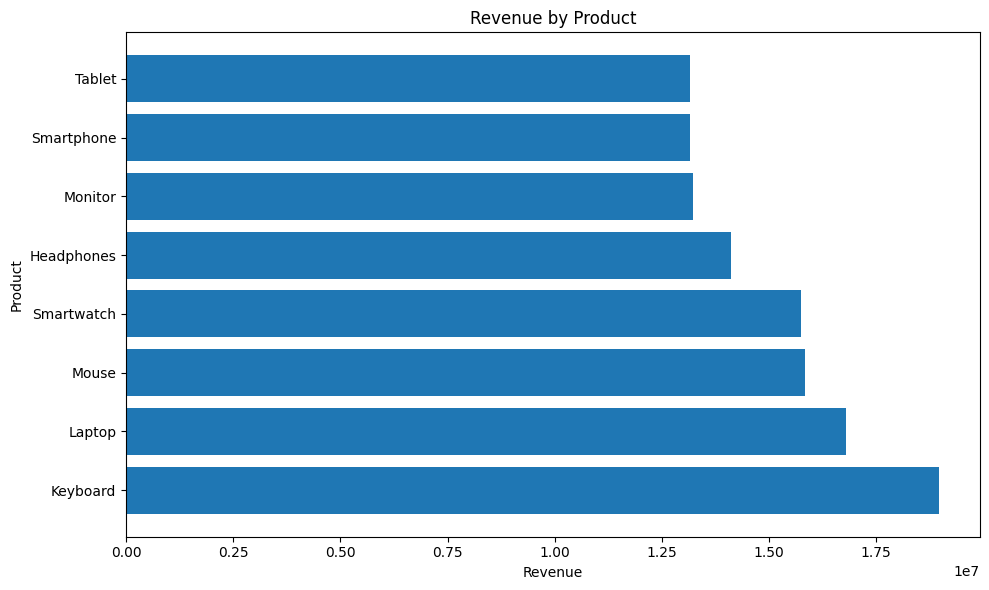

In [14]:
# Step 6: Product Revenue Chart

plt.figure(figsize=(10,6))
plt.barh(product_analysis.index, product_analysis.values)
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.title("Revenue by Product")
plt.tight_layout()
plt.show()

In [3]:
# Step 7: City Performance Analysis

city_analysis = df.groupby("City")["Revenue"].sum().sort_values(ascending=False)

print("Revenue by City:")
print(city_analysis)

Revenue by City:
City
Bengaluru    16795171
Pune         16361973
Delhi        16348939
Chennai      15922451
Kochi        15753750
Hyderabad    15496260
Mumbai       13120731
Tirupati     11176301
Name: Revenue, dtype: int64


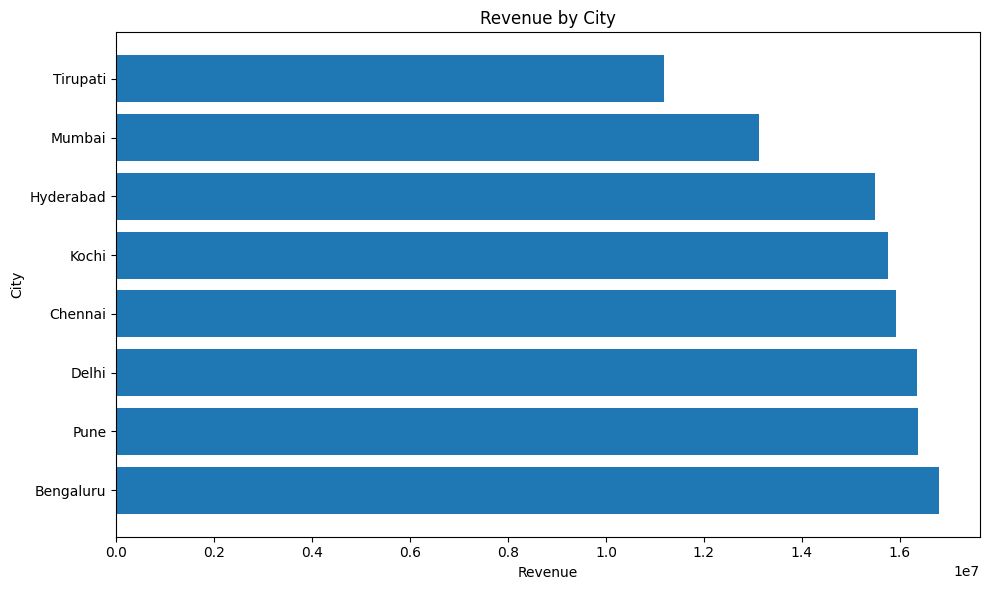

In [5]:
# Step 8: City Revenue Chart

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(city_analysis.index, city_analysis.values)
plt.xlabel("Revenue")
plt.ylabel("City")
plt.title("Revenue by City")
plt.tight_layout()
plt.show()

In [6]:
# Step 9: Monthly Sales Analysis

df["Month"] = df["Date"].dt.month

monthly_sales = df.groupby("Month")["Revenue"].sum()

print("Monthly Revenue:")
print(monthly_sales)

Monthly Revenue:
Month
1     11203718
2      8263076
3     11047177
4      8839872
5      9957537
6      9445579
7     10529162
8     10169437
9     10776075
10    10910246
11     9620358
12    10213339
Name: Revenue, dtype: int64


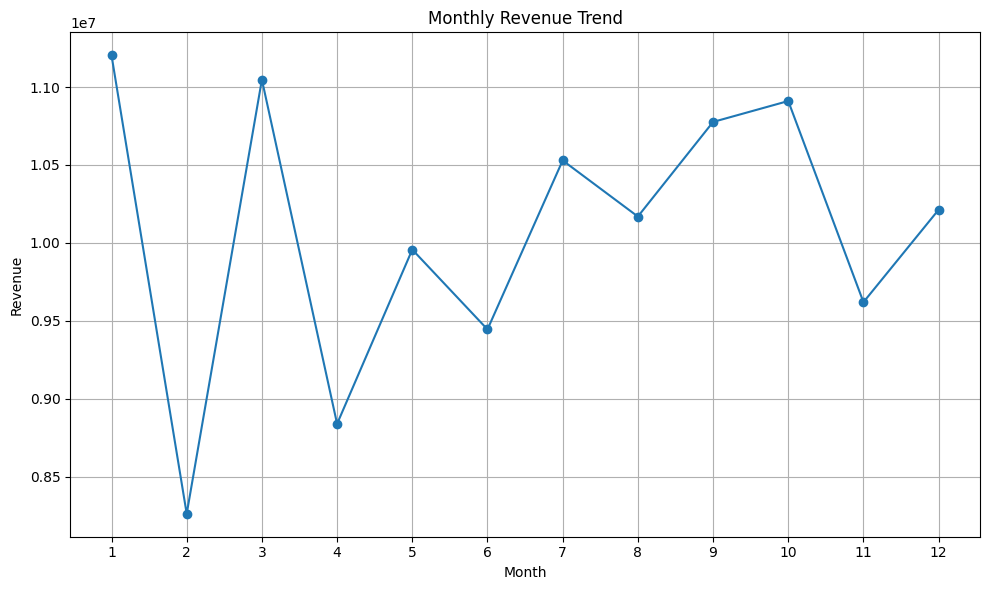

In [7]:
# Step 10: Monthly Revenue Chart

import matplotlib.pyplot as plt

df["Month"] = df["Date"].dt.month
monthly_sales = df.groupby("Month")["Revenue"].sum()

plt.figure(figsize=(10,6))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Monthly Revenue Trend")
plt.xticks(range(1,13))
plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
# Step 11: Profit Analysis

profit_analysis = df.groupby("Product")["Profit"].sum().sort_values(ascending=False)

print("Profit by Product:")
print(profit_analysis)

Profit by Product:
Product
Keyboard      3710871.66
Laptop        3357415.86
Smartwatch    3008377.88
Mouse         2977553.35
Headphones    2758869.54
Tablet        2660747.62
Monitor       2446230.57
Smartphone    2398958.78
Name: Profit, dtype: float64


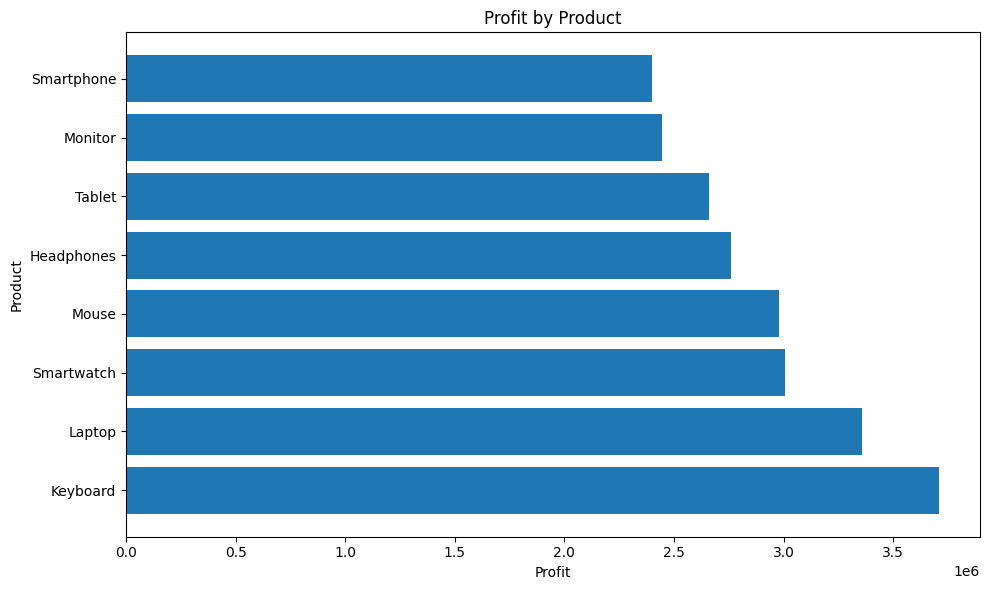

In [10]:
# Step 12: Profit by Product Chart

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(profit_analysis.index, profit_analysis.values)
plt.xlabel("Profit")
plt.ylabel("Product")
plt.title("Profit by Product")
plt.tight_layout()
plt.show()

In [11]:
# Step 13: Category Analysis

category_analysis = df.groupby("Category")["Revenue"].sum().sort_values(ascending=False)

print("Revenue by Category:")
print(category_analysis)

Revenue by Category:
Category
Electronics    56315824
Accessories    48918719
Wearables      15741033
Name: Revenue, dtype: int64


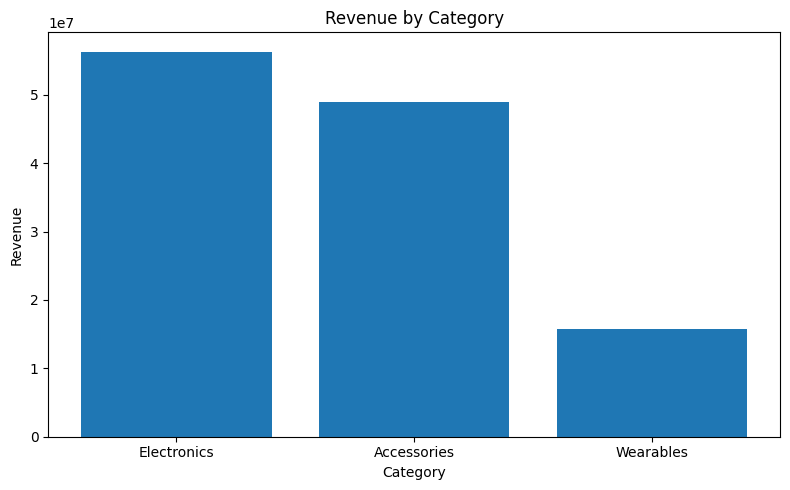

In [12]:
# Step 14: Category Revenue Chart

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(category_analysis.index, category_analysis.values)
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.title("Revenue by Category")
plt.tight_layout()
plt.show()

In [13]:
# Step 15: Top 5 Products

top_products = df.groupby("Product")["Revenue"].sum().sort_values(ascending=False).head(5)

print("Top 5 Products by Revenue:")
print(top_products)

Top 5 Products by Revenue:
Product
Keyboard      18971927
Laptop        16794359
Mouse         15839815
Smartwatch    15741033
Headphones    14106977
Name: Revenue, dtype: int64


In [14]:
# Step 16: Top 5 Cities

top_cities = df.groupby("City")["Revenue"].sum().sort_values(ascending=False).head(5)

print("Top 5 Cities by Revenue:")
print(top_cities)

Top 5 Cities by Revenue:
City
Bengaluru    16795171
Pune         16361973
Delhi        16348939
Chennai      15922451
Kochi        15753750
Name: Revenue, dtype: int64


In [15]:
# Step 17: Business Insights

best_product = df.groupby("Product")["Revenue"].sum().idxmax()
best_city = df.groupby("City")["Revenue"].sum().idxmax()
best_category = df.groupby("Category")["Revenue"].sum().idxmax()
best_month = df.groupby(df["Date"].dt.month)["Revenue"].sum().idxmax()

print("===== BUSINESS INSIGHTS =====")
print("Top Product:", best_product)
print("Top City:", best_city)
print("Top Category:", best_category)
print("Best Sales Month:", best_month)

===== BUSINESS INSIGHTS =====
Top Product: Keyboard
Top City: Bengaluru
Top Category: Electronics
Best Sales Month: 1


In [16]:
# Step 18A: Save Dataset

df.to_csv("sales_data.csv", index=False)

print("sales_data.csv saved successfully!")

sales_data.csv saved successfully!


In [17]:
# Step 18B: Create SQL Queries

sql_queries = """
-- Sales Data Analysis SQL Queries

-- 1. Total Revenue
SELECT SUM(Revenue) AS Total_Revenue
FROM sales_data;

-- 2. Total Profit
SELECT SUM(Profit) AS Total_Profit
FROM sales_data;

-- 3. Revenue by Product
SELECT Product, SUM(Revenue) AS Total_Revenue
FROM sales_data
GROUP BY Product
ORDER BY Total_Revenue DESC;

-- 4. Revenue by City
SELECT City, SUM(Revenue) AS Total_Revenue
FROM sales_data
GROUP BY City
ORDER BY Total_Revenue DESC;

-- 5. Revenue by Category
SELECT Category, SUM(Revenue) AS Total_Revenue
FROM sales_data
GROUP BY Category
ORDER BY Total_Revenue DESC;

-- 6. Top 5 Products
SELECT Product, SUM(Revenue) AS Total_Revenue
FROM sales_data
GROUP BY Product
ORDER BY Total_Revenue DESC
LIMIT 5;

-- 7. Monthly Revenue
SELECT MONTH(Date) AS Month, SUM(Revenue) AS Total_Revenue
FROM sales_data
GROUP BY MONTH(Date)
ORDER BY Month;
"""

print(sql_queries)


-- Sales Data Analysis SQL Queries

-- 1. Total Revenue
SELECT SUM(Revenue) AS Total_Revenue
FROM sales_data;

-- 2. Total Profit
SELECT SUM(Profit) AS Total_Profit
FROM sales_data;

-- 3. Revenue by Product
SELECT Product, SUM(Revenue) AS Total_Revenue
FROM sales_data
GROUP BY Product
ORDER BY Total_Revenue DESC;

-- 4. Revenue by City
SELECT City, SUM(Revenue) AS Total_Revenue
FROM sales_data
GROUP BY City
ORDER BY Total_Revenue DESC;

-- 5. Revenue by Category
SELECT Category, SUM(Revenue) AS Total_Revenue
FROM sales_data
GROUP BY Category
ORDER BY Total_Revenue DESC;

-- 6. Top 5 Products
SELECT Product, SUM(Revenue) AS Total_Revenue
FROM sales_data
GROUP BY Product
ORDER BY Total_Revenue DESC
LIMIT 5;

-- 7. Monthly Revenue
SELECT MONTH(Date) AS Month, SUM(Revenue) AS Total_Revenue
FROM sales_data
GROUP BY MONTH(Date)
ORDER BY Month;



In [2]:
# Step 19: Overall Sales Summary

import pandas as pd
import numpy as np

np.random.seed(42)
n = 1000

products = ["Laptop","Smartphone","Headphones","Keyboard","Mouse","Monitor","Tablet","Smartwatch"]
cities = ["Bengaluru","Hyderabad","Chennai","Mumbai","Delhi","Pune","Kochi","Tirupati"]
categories = dict(Laptop="Electronics",Smartphone="Electronics",Headphones="Accessories",Keyboard="Accessories",Mouse="Accessories",Monitor="Electronics",Tablet="Electronics",Smartwatch="Wearables")

df = pd.DataFrame()
df["Order_ID"] = [f"ORD{i:04d}" for i in range(1,n+1)]
df["Date"] = pd.date_range("2025-01-01","2025-12-31",periods=n)
df["Product"] = np.random.choice(products,n)
df["City"] = np.random.choice(cities,n)
df["Quantity"] = np.random.randint(1,6,n)
df["Unit_Price"] = np.random.randint(500,80000,n)
df["Category"] = df["Product"].map(categories)
df["Revenue"] = df["Quantity"] * df["Unit_Price"]
df["Profit"] = (df["Revenue"] * np.random.uniform(0.08,0.30,n)).round(2)

total_revenue = df["Revenue"].sum()
total_profit = df["Profit"].sum()
total_quantity = df["Quantity"].sum()
average_order_value = df["Revenue"].mean()

print("===== SALES SUMMARY =====")
print("Total Revenue: ₹",round(total_revenue,2))
print("Total Profit: ₹",round(total_profit,2))
print("Total Quantity Sold:",total_quantity)
print("Average Order Value: ₹",round(average_order_value,2))

===== SALES SUMMARY =====
Total Revenue: ₹ 120975576
Total Profit: ₹ 23319025.26
Total Quantity Sold: 3038
Average Order Value: ₹ 120975.58


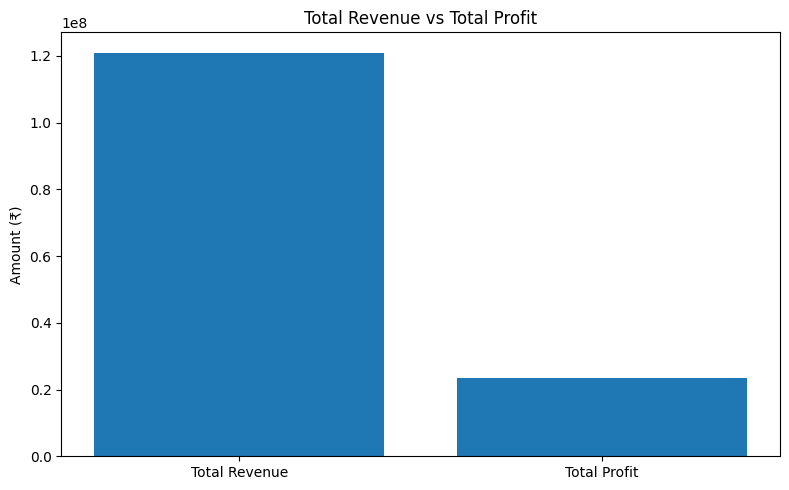

In [3]:
# Step 20: Revenue vs Profit Chart

import matplotlib.pyplot as plt

revenue = df["Revenue"].sum()
profit = df["Profit"].sum()

plt.figure(figsize=(8,5))
plt.bar(["Total Revenue","Total Profit"],[revenue,profit])
plt.ylabel("Amount (₹)")
plt.title("Total Revenue vs Total Profit")
plt.tight_layout()
plt.show()

In [4]:
# Step 21: Save Final Dataset

df.to_csv("sales_data_final.csv", index=False)

print("Final dataset saved successfully!")
print("Rows:", len(df))
print("Columns:", len(df.columns))

Final dataset saved successfully!
Rows: 1000
Columns: 9


In [7]:
# Step 22: Create SQL File

sql = """-- Sales Data Analysis SQL Queries

-- 1. Total Revenue
SELECT SUM(Revenue) AS Total_Revenue
FROM sales_data;

-- 2. Total Profit
SELECT SUM(Profit) AS Total_Profit
FROM sales_data;

-- 3. Revenue by Product
SELECT Product, SUM(Revenue) AS Total_Revenue
FROM sales_data
GROUP BY Product
ORDER BY Total_Revenue DESC;

-- 4. Revenue by City
SELECT City, SUM(Revenue) AS Total_Revenue
FROM sales_data
GROUP BY City
ORDER BY Total_Revenue DESC;

-- 5. Revenue by Category
SELECT Category, SUM(Revenue) AS Total_Revenue
FROM sales_data
GROUP BY Category
ORDER BY Total_Revenue DESC;

-- 6. Top 5 Products
SELECT Product, SUM(Revenue) AS Total_Revenue
FROM sales_data
GROUP BY Product
ORDER BY Total_Revenue DESC
LIMIT 5;

-- 7. Monthly Revenue
SELECT MONTH(Date) AS Month, SUM(Revenue) AS Total_Revenue
FROM sales_data
GROUP BY MONTH(Date)
ORDER BY Month;
"""

open("analysis_queries.sql","w").write(sql)

print("analysis_queries.sql created successfully!")

analysis_queries.sql created successfully!


In [8]:
# Step 23: Create Requirements File

requirements = """pandas
numpy
matplotlib
jupyter
"""

open("requirements.txt","w").write(requirements)

print("requirements.txt created successfully!")

requirements.txt created successfully!


In [9]:
# Step 24: Create README File

readme = """# Sales Data Analysis using Python & SQL

## Project Overview

This project analyzes a sales dataset using Python, Pandas, NumPy, Matplotlib and SQL.

The objective is to identify sales trends, product performance, city performance, profitability and important business insights.

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- SQL
- Google Colab

## Analysis Performed

- Data cleaning and quality checking
- Sales KPI calculation
- Product revenue analysis
- City revenue analysis
- Monthly revenue analysis
- Profit analysis
- Category analysis
- Top product identification
- Business insights
- SQL business queries

## Dataset

The dataset contains 1,000 sales transactions from 2025.

Columns include:

- Order_ID
- Date
- Product
- City
- Quantity
- Unit_Price
- Category
- Revenue
- Profit

## Project Structure

sales-data-analysis-python/

- data/
- notebooks/
- sql/
- README.md
- requirements.txt
- .gitignore

## Author

Sri Chaithanya

Data Analytics Portfolio Project
"""

open("README.md","w").write(readme)

print("README.md created successfully!")

README.md created successfully!


In [11]:
import zipfile
import os

os.makedirs("project", exist_ok=True)

df.to_csv("project/sales_data_final.csv", index=False)

open("project/analysis_queries.sql","w").write(sql)

open("project/requirements.txt","w").write("pandas\nnumpy\nmatplotlib\njupyter\n")

open("project/README.md","w").write(readme)

open("project/.gitignore","w").write("__pycache__/\n.ipynb_checkpoints/\n*.pyc\n")

files = [
"project/sales_data_final.csv",
"project/analysis_queries.sql",
"project/requirements.txt",
"project/README.md",
"project/.gitignore"
]

with zipfile.ZipFile("sales-data-analysis-python.zip","w") as z:
    for f in files:
            z.write(f)

            print("PROJECT ZIP CREATED!")

PROJECT ZIP CREATED!
PROJECT ZIP CREATED!
PROJECT ZIP CREATED!
PROJECT ZIP CREATED!
PROJECT ZIP CREATED!
